# <b>Sixth Stage: Evaluation of NADH Production After Enzyme Flux Modifications</b>

## 6.1 Enzyme Space Restriction

<div style='text-align: justify'>The main enzymes identified by the Random Forest algorithm will now be selected, and their fluxes will be varied within the minimum and maximum permissible ranges. Note that these ranges are not exactly those obtained from FVA; instead, they correspond to the maximum and minimum flux values that can be assigned to the enzymes without producing an infeasible solution (here, infeasible refers to the absence of biomass production). As previously suggested, our main objective is to reduce the number of selected enzymes to one or two, so that NADH maximization occurs with the minimum number of required genetic modifications. Although certain flux combinations involving many enzymes can lead to NADH production above high yields, implementing and maintaining multiple enzymatic modifications in <i>in vitro</i> experiments would be complex and labor intensive. This way, to assess which enzymes are the best candidates for NADH maximization, we developed an interactive algorithm to visualize, in real time, the changes in TCA cycle enzyme fluxes resulting from modifications in the fluxes of the main enzymes identified by the machine learning model. Additionally, the production of both NADH and biomass will be evaluated for each enzyme modification, enabling a more precise identification of the flux conditions that lead to NADH maximization.</div><br>

<div style='text-align: justify'>The selected enzymes for modification wil be:</div>
<ol>
    <li><b>AKGDH</b></li>
    <li><b>CS</b></li>
    <li><b>PPC</b></li>
    <li><b>FRD2</b></li>
</ol>
<div style='text-align: justify'>Since they were the main factors responsible for the discrimination performed by the machine learning model.</div>

In [1]:
# For data loading and manipulation
import pandas as pd
import numpy as np

# For generation of combinations
import itertools

# Model loading and manipulation
import cobra
from cobra.io import load_json_model

# For data visualization
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Functions constantly used on codes
import functions as f

# Tools for metabolic visualization (import in escher environment)
# import escher
# from IPython.display import display
# from escher import Builder

In [4]:
# model loading
# model = load_json_model('../Models/EC_iCH360.json')

In [3]:
model

Name,EC_iCH360
Memory address,7f3058d9ba90
Number of metabolites,305
Number of reactions,505
Number of genes,356
Number of groups,0
Objective expression,1.0*Biomass_fw - 1.0*Biomass_fw_reverse_bf19d
Compartments,"cytosol, extracellular space, periplasm"


In [3]:
model_anaero = model.copy()

Read LP format model from file /tmp/tmpz2ks8w2g.lp
Reading time = 0.00 seconds
: 305 rows, 1010 columns, 4816 nonzeros


In [4]:
# Simulating an anaerobic environment
model_anaero.reactions.get_by_id('EX_o2_e_bw').bounds = (0,0)

## 6.2 Visualization of TCA Cycle Enzyme Behavior

In [5]:
# Max flux possible for AKGDH_fw
akg_max = f.Max(model_anaero,'AKGDH_fw')

f.interactive_changes(model_anaero, 'AKGDH_fw', 0.0, akg_max)

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


interactive(children=(FloatSlider(value=0.0, description='slide', max=2.6899999999999866, step=0.001), Output(…

In [6]:
# Max flux possible for PPC_fw
ppc_max = f.Max(model_anaero,'PPC_fw')

f.interactive_changes(model_anaero, 'PPC_fw', 0.4125075038638759, ppc_max)

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


interactive(children=(FloatSlider(value=0.4125075038638759, description='slide', max=28.550000000001663, step=…

In [6]:
# Max flux possible for CS_fw
cs_max = f.Max(model_anaero,'CS_fw')

f.interactive_changes(model_anaero, 'CS_fw', 0.1105232674676028, cs_max)

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


interactive(children=(FloatSlider(value=0.1105232674676028, description='slide', max=3.849999999999962, step=0…

In [8]:
# Max flux possible for AKGDH_fw
frd2_max = f.Max(model_anaero,'FRD2_fw')

f.interactive_changes(model_anaero, 'FRD2_fw', 0.10725614095158353, frd2_max)

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


interactive(children=(FloatSlider(value=0.10725614095158353, description='slide', max=10.199999999999827, step…

<div style='text-align: justify'>Some interesting points are worth discussing:</div>
<ul>
    <li><b>AKGDH:</b> By AKGDH overexpression, the model achieves a maximal NADH production of 24 before the objective becomes infeasible. Through this modification, the oxidative branch of the TCA cycle is induced, in which enzymes PPC, CS, ACONTa, ACONTb, and ICDHyr have the same flux value as AKGDH. Nonetheless, SUCOAS is not activated, indicating that succinyl-CoA is the last metabolite produced by the cycle. Thus, we can conclude that AKGDH has a strong influence on TCA cycle entry and maintenance under anaerobic conditions. However, despite being the most influential enzyme for the machine learning model discrimination, it does not have the capacity to maximize NADH as observed for PPC (see below).</li><br>
    <li><b>PPC</b>: By far, PPC is the enzyme with the highest upper bound for overexpression in the model, achieving a maximal flux of approximately 30 mmol/gDW/h before FBA becomes infeasible. In contrast, even with this wide range of variation, PPC seems to have little impact on TCA cycle enzymes, which can be observed from the response of the remaining enzymes after PPC overexpression. However, NADH production is directly related to PPC flux, such that NADH can reach values of up to 35 mmol/gDW/h, exceeding those observed under wild-type aerobic conditions. Given the limited influence of PPC on TCA cycle enzymes, we can hypothesize that NADH maximization primarily results from glycolysis, which is likely induced by PPC overexpression.</li><br>
    <li><b>CS:</b> CS overexpression leads to a behavior in the TCA cycle very similar to that observed with AKGDH overexpression, in which the oxidative branch is induced. However, in this case, the cycle stops at 2-oxoglutarate production, since AKGDH is not induced. This behavior is particularly interesting for our future purposes of HydABC flux maximization through OGOR expression, as the enzyme could be favored by increased 2-oxoglutarate synthesis and HydABC by NADH maximization (see Part 8).</li><br>
    <li><b>FRD2:</b> Finally, FRD2 shows a very distinct influence on the selected enzymes compared to those mentioned above. With FRD2 overexpression, PPC, MDH, and FUM are heavily induced. However, all other TCA cycle enzymes are repressed, indicating that this overexpression is not sufficient to maintain the cycle active. It is also noteworthy that ppc is activated by FRD2 overexpression, an enzyme directly involved in NADH production. Nonetheless, regarding NADH production, FRD2 does not appear to be a strong candidate.</li>
</ul>

<div style='text-align: justify'>Thus, we conclude that PPC is the most suitable enzyme for the purposes of this analysis, as it provides the highest NADH maximization without excessively impairing biomass production. Additionally, CS will also be selected for further analysis, as it represents a promising candidate in the context of OGOR expression. We now assess how bacterial metabolism is altered by the overexpression of each enzyme.</div>

## 6.3 Differences in NADH Production from Individual Overexpression of PPC and CS

<div style='text-align: justify'>Since PPC and CS overexpression under anaerobic conditions leads to different levels of NADH production, it is important to examine how each enzyme individually influences NADH synthesis by analyzing their effects on enzymes involved in cofactor production and consumption.</div>

In [ ]:
# CS overexpression (the value for CS overexpression represents a flux that leads to 21 mmol/gDW/h of NADH and biomass production of 0.024 h⁻¹)
with model_anaero:
    model_anaero.reactions.get_by_id('CS_fw').bounds = (3.0,3.0)
    solution_cs = model_anaero.optimize()

# PPC overexpression (the value for PPC overexpression represents a flux that leads to 31 mmol/gDW/h of NADH and biomass production of 0.024 h⁻¹)
with model_anaero:
    model_anaero.reactions.get_by_id('PPC_fw').bounds = (22.28,22.28)
    solution_ppc = model_anaero.optimize()

In [17]:
limit = 0.01
metabolite = 'nadh_c'

df_nadh_ppc = f.metabolite_df(model_anaero,solution_ppc,metabolite,limit)
df_nadh_cs = f.metabolite_df(model_anaero,solution_cs,metabolite,limit)

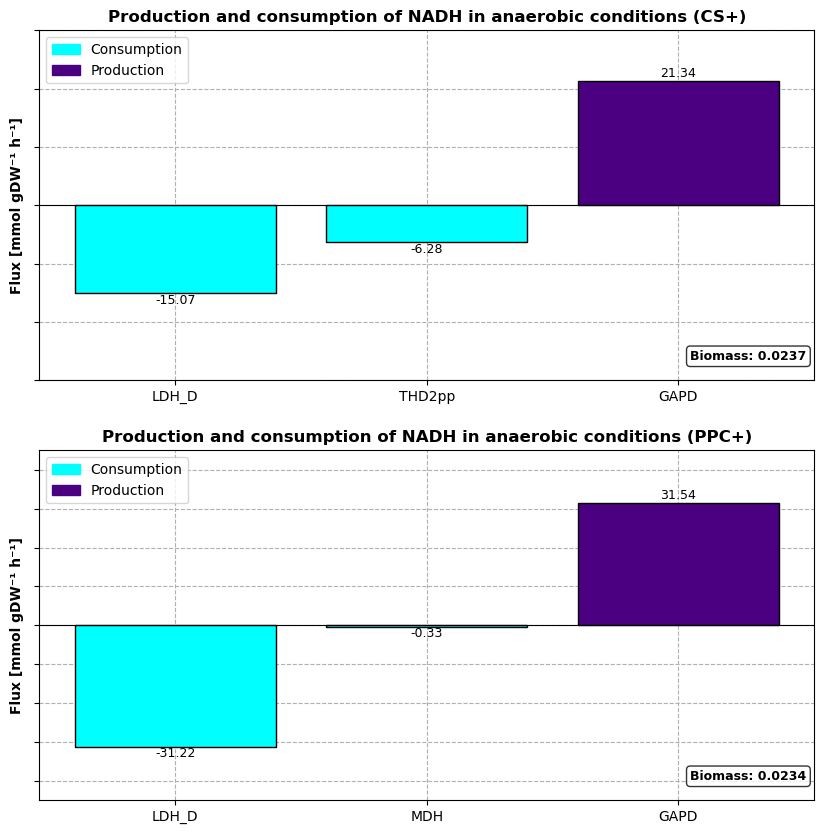

In [19]:
fig = plt.figure(figsize=(10,10))
gs = GridSpec(2, 1,figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

f.plot_df(df_nadh_cs, 
          "Production and consumption of NADH in anaerobic conditions (CS+)", 
          [-30,30], 
          round(solution_cs.objective_value,4), 
          ax=ax1)

f.plot_df(df_nadh_ppc, 
          "Production and consumption of NADH in anaerobic conditions (PPC+)", 
          [-45,45], 
          round(solution_ppc.objective_value,4), 
          ax=ax2)

#fig.savefig('../Images/NADH_CS_ppc_OverSep.png',dpi=1200)

<div style='text-align: justify'>Considering equal biomass production for the selected strains, we observe that both overexpressions rely on the same mechanism: induction of glyceraldehyde-3-phosphate dehydrogenase (GAPD) flux through maximization of glycolysis. As indicated by the interactive function, PPC is strongly capable of generating high glycolytic fluxes, maximizing NADH production to levels above those observed in wild-type anaerobic metabolism. Similarly, CS overexpression also leads to an improvement in glycolysis, but to a considerably lower extent. The similarities between these modifications are also reflected in the consuming enzymes, in which lactate dehydrogenase (LDH) is the main enzyme responsible for NADH consumption. Thus, if HydABC flux improvement is the desired objective, LDH should be considered a promising candidate for knockout, increasing NADH availability for the heterologously expressed enzyme.</div>

## 6.4 Differences in ATP Production from Individual Overexpression of PPC and CS

In [32]:
limit = 0.01
metabolite = 'atp_c'

df_atp_ppc = f.metabolite_df(model_anaero,solution_ppc,metabolite,limit)
df_atp_cs = f.metabolite_df(model_anaero,solution_cs,metabolite,limit)

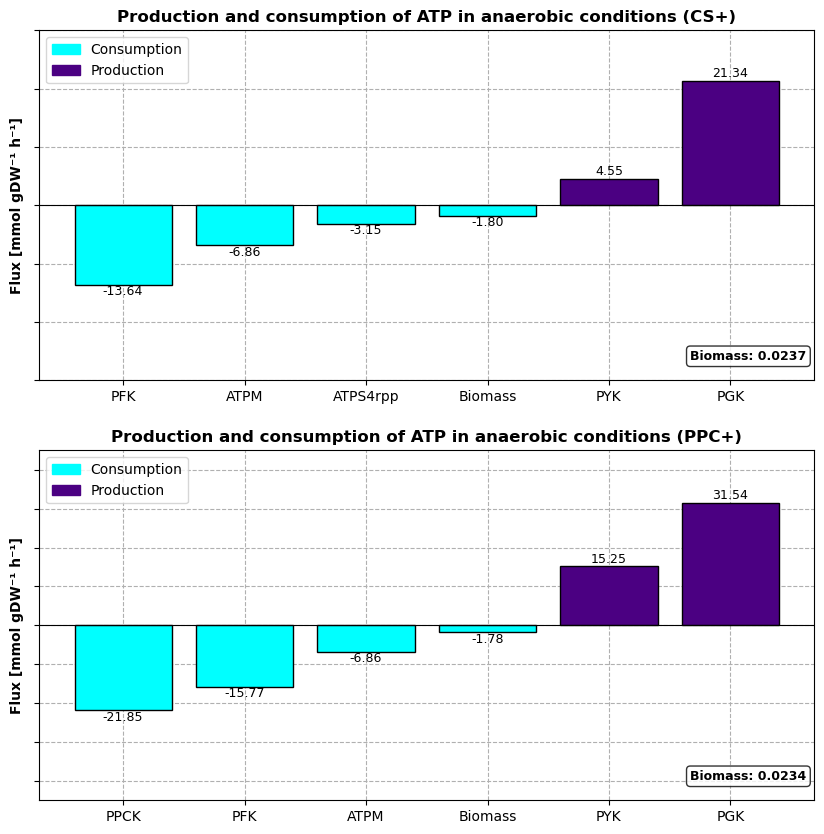

In [35]:
fig = plt.figure(figsize=(10,10))
gs = GridSpec(2, 1,figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

f.plot_df(df_atp_cs, 
          "Production and consumption of ATP in anaerobic conditions (CS+)", 
          [-30,30], 
          round(solution_cs.objective_value,4), 
          ax=ax1)

f.plot_df(df_atp_ppc, 
          "Production and consumption of ATP in anaerobic conditions (PPC+)", 
          [-45,45], 
          round(solution_ppc.objective_value,4), 
          ax=ax2)

#fig.savefig('../Images/ATP_CS_ppc_OverSep.png',dpi=1200)

<div style='text-align: justify'>Qualitatively, both scenarios remain almost unchanged, with one main difference: activation of phosphoenolpyruvate carboxykinase (PPCK) under PPC overexpression. As shown by the PPC overexpression results, PPCK must be activated to compensate for oxaloacetate production by PPC. The anaplerotic reaction for oxaloacetate is not sufficient to induce the TCA cycle. Instead, the metabolite is redirected toward glycolytic flux by PPCK at the expense of 1 mol of ATP.</div>

## 6.5 Effects of PPC and CS Overxpression on Overall Metabolism

<div style='text-align: justify'>At this stage of the analysis, it is important to determine how modifications in CS and PPC fluxes affect other enzymes in <i>E. coli</i> metabolism. To accomplish this, the <b>wild-type anaerobic metabolism of the iCH360 model (Part 1) will be used as the control condition and compared with two distinct scenarios:</b> </div>
<ol>
    <li><b>CS overexpression</b>;</li>
    <li><b>PPC overexpression</b>;</li>
</ol>
<div style='text-align: justify'>Each scenario will be compared with the control group, and the enzymes showing the largest differences between conditions will be displayed in a heat map. The difference in reaction rates between each scenario and the control condition will be quantified using the $log_2\text{ FC}$ metric, defined as follows:</div>

$$log_2(\frac{\text{Flux after modification}}{\text{Flux on control situation}})$$

<div style='text-align: justify'>To avoid division by zero, an $\epsilon$ value of 0.01 will be added to both the numerator and the denominator in the $log_2\text{ FC}$ calculation. In this way, the analysis provides a clear view of which enzymes are most influenced by the modifications.</div>

In [20]:
# Let us first define the control group.
with model_anaero:
    solution_control = model_anaero.optimize()

In [21]:
# Creation of data frames of scenarios
# Since solution.fluxes returns a Series object, it must be converted into a DataFrame in order to be plotted.

# log2 FC in ppc overexpression
ppc_ser_FC = (solution_ppc.fluxes + 0.01) / (solution_control.fluxes + 0.01)
ppc_ser_log = np.log2(ppc_ser_FC)

# ppc data frame
ppc_df = pd.DataFrame(ppc_ser_log)
ppc_df = ppc_df.sort_values(by='fluxes',key=abs,ascending=False).iloc[0:20]
ppc_df = ppc_df.sort_values(by='fluxes',ascending=False).iloc[0:20]
ppc_df.rename(columns={'fluxes': 'PPC Over'}, inplace=True)

# log2 FC in CS overexpression
cs_ser_FC = (solution_cs.fluxes + 0.01) / (solution_control.fluxes + 0.01)
cs_ser_log = np.log2(cs_ser_FC)

# CS data frame
cs_df = pd.DataFrame(cs_ser_log)
cs_df = cs_df.sort_values(by='fluxes',key=abs,ascending=False).iloc[0:20]
cs_df = cs_df.sort_values(by='fluxes',ascending=False).iloc[0:20]
cs_df.rename(columns={'fluxes': 'CS Over'}, inplace=True)

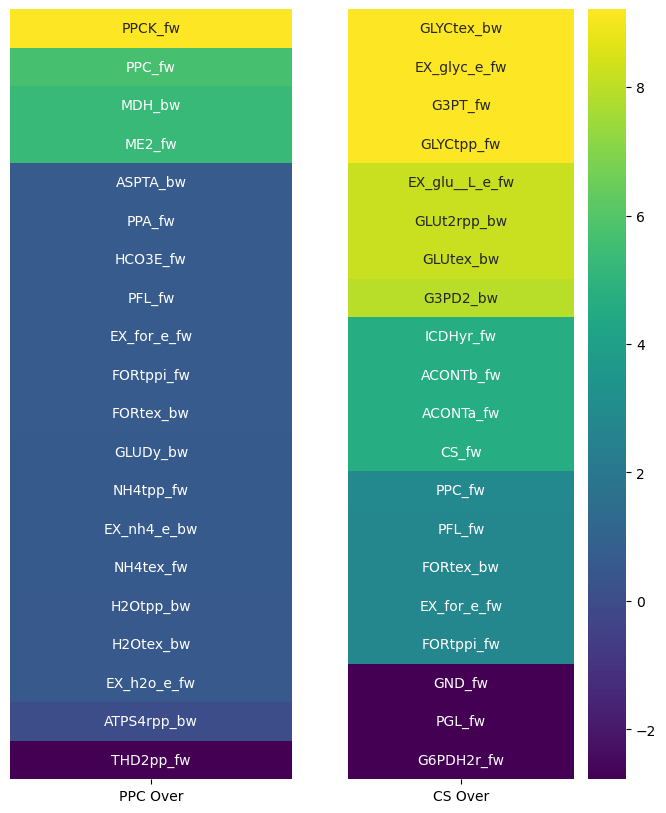

In [28]:
# Plotting the heatmaps. The visualization will be restricted to the 20 enzymes that show the greatest variation relative to the control condition.
fig = plt.figure(figsize=(8,10))
gs = GridSpec(1, 2,figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

labels_ppc = pd.DataFrame({'Enzymes':ppc_df.index})
labels_CS = pd.DataFrame({'Enzymes':cs_df.index})

sns.heatmap(ppc_df.iloc[0:20], annot=labels_ppc, cmap='viridis',fmt="",yticklabels=False,ax=ax1,cbar=False)
sns.heatmap(cs_df.iloc[0:20], annot=labels_CS, cmap='viridis',fmt="",yticklabels=False,ax=ax2,cbar=True)

#fig.savefig('../Images/Heatmap.png',dpi=1200)

<div style='text-align: justify'>The results for each scenario will now be examined individually.</div><br>

<div style='text-align: justify'><b>PPC Overexpression:</b>The most prominent metabolic changes in <i>E. coli</i> following PPC overexpression include the inactivation of several pathways, such as formate production and export; amino acid production pathways; ATP consumption via ATP synthase; and water transport across the membrane. However, the most interesting observation is that succinate production is not affected by PPC overexpression, despite being one of the most impacted metabolites in <i>in vitro</i> experiments (<a href="https://doi.org/10.1128/AEM.00826-13">2013</a>). In fact, an increase in succinate production could explain the observed improvement in NADH levels, since its formation involves NADH reoxidation, leading to NAD⁺ regeneration and enabling glycolysis to proceed. Nonetheless, this behavior is not observed in the present analysis. Therefore, a more detailed explanation for NADH improvement under PPC overexpression cannot be fully addressed within the scope of this project.</div><br>

<div style='text-align: justify'><b>CS Overexpression:</b> At first, we observe that CS overexpression results in a reduction of flux through the oxidative branch of the pentose phosphate pathway (PPP), as evidenced by decreased activity of its associated enzymes. A similar comparison can be made regarding the glycerol production pathway, which is strongly induced under CS overexpression. However, the mechanistic link between CS activity, PPP downregulation, and increased glycerol synthesis remains unclear and requires further investigation. Given that CS is a key entry point into the TCA cycle, its overexpression directly impacts the activation of several downstream enzymes, particularly the aconitase complex (ACONTa and ACONTb) and isocitrate dehydrogenase (ICDHyr). The absence of induction in &alpha;-ketoglutarate dehydrogenase (AKGDH_fw) may be explained by constraints related to NADH accumulation, which could limit biomass formation. Instead, &alpha;-ketoglutarate is likely redirected toward glutamate biosynthesis, supported by the observed induction of amino acid transport systems. This interpretation is consistent with <i>in vitro</i> observations, such as those reported by Kiira et al. (<a href="https://doi.org/10.1186/s13568-015-0147-y">2015</a>), where increased expression of CS and aconitase under anaerobic conditions led to enhanced glutamate production. Additionally, CS overexpression leads to increased activity of both PFL and PPC. The induction of PPC is plausibly linked to the need for oxaloacetate replenishment, ensuring that CS can sustain flux through the TCA cycle via anaplerotic reactions. In parallel, the activation of PFL suggests a compensatory mechanism to maintain acetyl-CoA supply while limiting PDH contribution. Together, PPC and PFL appear to support substrate availability for continued CS activity. </div><br>

<div style='text-align: justify'>Now, concluding Part 6, let us examine how NADH production is improved by the overexpression of the selected enzymes: AKGDH, PPC, and CS.</div><br>

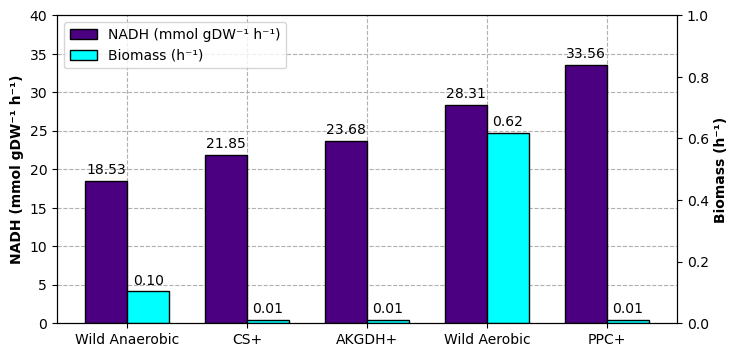

In [49]:
# Creation of the bar plot containing H2 production of strains SP5, SP6, SP7 and PO2

nadh = [18.5269,21.854327,23.682184,28.3102,33.560886]
biomass = [0.1032,0.011728,0.011792,0.6167,0.011351]

strains = ['Wild Anaerobic','CS+','AKGDH+','Wild Aerobic','PPC+']

x = np.arange(len(strains))  
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))

ax_1 = ax.twinx()

rects_1 = ax.bar(x-width/2, nadh, width, label='NADH (mmol gDW⁻¹ h⁻¹)', color='indigo', edgecolor='black')
ax.set_ylabel('NADH (mmol gDW⁻¹ h⁻¹)', weight='bold')
ax.set_ylim(0, 40)
ax.bar_label(rects_1, padding=3, fmt='%.2f')
ax.set_xticks(x, strains)
ax.grid(linestyle='dashed')
ax.set_axisbelow(True)

rects_2 = ax_1.bar(x+width/2, biomass, width, label='Biomass (h⁻¹)', color='cyan', edgecolor='black')
ax_1.set_ylabel('Biomass (h⁻¹)', weight='bold')
ax_1.set_ylim(0, 1)
ax_1.bar_label(rects_2, padding=3, fmt='%.2f')


handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_1.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.show()
fig.savefig('../Images/NADH_strains_bar.png',dpi=1200)

# <b>End of Part 6!</b>